# PASSO 4: Notebook para inferência de estoque total de CO2

**Pipeline MORE · CO₂ incorporado** — 4 de 4

Cruza os índices de referência por pavimento (do Passo 3) com os polígonos das
edificações (LiDAR) para estimar o estoque total de CO₂ incorporado da comunidade,
em três cenários (mínimo, central, máximo).

| | |
|---|---|
| **Entradas** | `indices_referencia_por_pavimento.xlsx` (⚠️ do **Passo 3**, não do consolidado), shapefile das edificações |
| **Saídas** | `mapa_eco2_sao_remo.png`, `totais_cenarios_todos_indices.png` |

> **Dependência não óbvia:** este passo **não** lê o `consolidado_geral.xlsx`. Ele
> depende do `indices_referencia_por_pavimento.xlsx`, que só é gerado quando a
> **última seção do Passo 3** ("Índices finais para a favela") é executada. Rode
> aquela seção antes deste notebook.

## Alternativa: QGIS

Todo este passo pode ser reproduzido no QGIS, sem código: importe os índices como
tabela, faça um *join* com a camada de polígonos pelo número de pavimentos e crie
um campo calculado aplicando a mesma regra de empilhamento (ver seção 3). O mapa
coroplético e os totais saem das ferramentas nativas de simbologia e estatística.
Este notebook existe para automatizar o processo quando ele é repetido.

In [ ]:
# ==============================================================================
# Passo 4 — Inferência do estoque de CO₂ incorporado (Comunidade São Remo)
#
# Índices por pavimento:  indices_referencia_por_pavimento.xlsx  (gerado no Passo 3)
# Polígonos das edificações:  shapefile LiDAR  (colunas 'area' e 'num_pav1')
# ==============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker


## 1. Índices de referência por pavimento

Carrega a tabela do Passo 3 e monta o dicionário `indices`, que guarda, para cada
número de pavimentos, os valores de ECO₂ nos três cenários (mín/central/máx). Esta
célula usa o **ECO₂ máximo** como índice principal de inferência; a célula final
recarrega todos os índices para o gráfico comparativo.

In [7]:
# ==============================================================================
# 1. CARREGAR ÍNDICES DE REFERÊNCIA
# ==============================================================================
df_idx = pd.read_excel("indices_referencia_por_pavimento.xlsx")

# Filtrar apenas ECO₂ máximo — índice principal para inferência
df_eco2 = df_idx[df_idx['Índice'] == 'ECO₂ máximo (kg/m²)'].copy()

# Mapa: nível do pavimento → índices dos três cenários
# Estrutura: {num_pav: {'min': val, 'central': val, 'max': val}}
indices = {}
for _, row in df_eco2.iterrows():
    pav_label = row['Pavimento']
    # Mapear label → número de pavimentos
    num = {'Térreo': 1, 'Pavimento 1': 2, 'Pavimento 2': 3, '≥ Pavimento 3': 4}.get(pav_label)
    if num is not None:
        indices[num] = {
            'min':     row['Cenário mínimo'],
            'central': row['Central (média)'],
            'max':     row['Cenário máximo'],
        }

print("Índices carregados:")
for k, v in indices.items():
    print(f"  {k} pavimento(s): mín={v['min']:.1f} | central={v['central']:.1f} | máx={v['max']:.1f} kg/m²")


Índices carregados:
  1 pavimento(s): mín=145.4 | central=219.9 | máx=294.5 kg/m²
  2 pavimento(s): mín=126.0 | central=186.0 | máx=246.1 kg/m²
  3 pavimento(s): mín=104.4 | central=158.4 | máx=212.3 kg/m²
  4 pavimento(s): mín=162.1 | central=162.1 | máx=162.1 kg/m²


## 2. Polígonos das edificações (shapefile LiDAR)

Carrega a camada de polígonos das edificações. O shapefile **precisa conter**:

- **`area`** — área de projeção (footprint) de cada edificação, em m².
- **`num_pav1`** — número de pavimentos de cada edificação.

O caminho abaixo é absoluto — ajuste para o seu ambiente (sugestão:
`data/external/Favela_SaoRemo_SHP/`). O CRS é detectado automaticamente; a célula
do mapa reprojeta para SIRGAS 2000 / UTM 23S (EPSG:31983) apenas para visualização.

In [8]:
# ==============================================================================
# 2. CARREGAR SHAPEFILE
# ==============================================================================
gdf = gpd.read_file("/data/external/Sao_remo.shp")   # ← ajuste o caminho

print(f"\nPolígonos carregados: {len(gdf)}")
print(f"CRS: {gdf.crs}")
print(f"Colunas: {gdf.columns.tolist()}")
print(gdf[['area', 'num_pav1']].describe().round(1))


Polígonos carregados: 1237
CRS: EPSG:31983
Colunas: ['fid', 'ClusterID', 'HeightAbov', 'area', 'num_pav1', 'area_const', 'numpav2', 'area_cons2', 'geometry']
         area  num_pav1
count  1237.0    1237.0
mean     66.0       2.6
std      94.3       0.9
min       2.1       1.0
25%      21.9       2.0
50%      36.9       3.0
75%      69.2       3.0
max    1261.4       6.0


## 3. Regra de empilhamento por pavimento

O ECO₂ de cada edificação é a soma das contribuições de cada nível, sempre
multiplicadas pela área de projeção (`area`):

- **1 pavimento:** índice do térreo × área.
- **2 pavimentos:** + índice do Pavimento 1 × área.
- **3 pavimentos:** + índice do Pavimento 2 × área.
- **≥ 4 pavimentos:** + (nº pav − 3) × índice do "≥ Pavimento 3" × área.

Ou seja, do 4º pavimento em diante todos os níveis extras usam o mesmo índice de
referência. Edificações com `num_pav1` ausente ou ≤ 0 retornam `NaN` (excluídas).
Os totais são convertidos de kg para toneladas (÷ 1000).

In [9]:
# ==============================================================================
# 3. LÓGICA DE CÁLCULO DO ECO₂ POR EDIFICAÇÃO
#    Conforme Quadro 1 do relatório:
#    1 pav  → idx_terreo * area
#    2 pavs → idx_terreo * area + idx_pav1 * area
#    3 pavs → idx_terreo * area + idx_pav1 * area + idx_pav2 * area
#    ≥4 pavs→ acima + (n-3) * idx_pav3 * area
# ==============================================================================
def calcular_eco2(area, num_pav, cenario):
    """Calcula ECO₂ total (kg) de uma edificação dado área, nº pavimentos e cenário."""
    idx = {k: v[cenario] for k, v in indices.items()}

    if num_pav <= 0 or pd.isna(num_pav):
        return np.nan

    total = idx[1] * area                          # térreo — sempre presente

    if num_pav >= 2:
        total += idx[2] * area                     # pavimento 1

    if num_pav >= 3:
        total += idx[3] * area                     # pavimento 2

    if num_pav >= 4:
        total += (num_pav - 3) * idx[4] * area     # pavimentos ≥ 3

    return total

# Calcular os três cenários (resultado em toneladas de CO₂ → dividir por 1000)
for cenario in ['min', 'central', 'max']:
    gdf[f'eco2_{cenario}_kg'] = gdf.apply(
        lambda row: calcular_eco2(row['area'], row['num_pav1'], cenario), axis=1)
    gdf[f'eco2_{cenario}_t']  = gdf[f'eco2_{cenario}_kg'] / 1000

# ECO₂ por m² (cenário central — para mapa coroplético)
gdf['area_total'] = gdf.apply(
    lambda row: row['area'] * max(row['num_pav1'], 1), axis=1)
gdf['eco2_m2'] = gdf['eco2_central_kg'] / gdf['area_total']

## 4. Estoque total da comunidade por cenário

In [10]:
# ==============================================================================
# 4. TOTAIS DA FAVELA POR CENÁRIO
# ==============================================================================
totais = {
    cenario: gdf[f'eco2_{cenario}_t'].sum()
    for cenario in ['min', 'central', 'max']
}

print("\n=== ESTOQUE TOTAL DE ECO₂ — SÃO REMO ===")
for cenario, total in totais.items():
    print(f"  {cenario.capitalize():8s}: {total:,.1f} tCO₂".replace(',', 'X').replace('.', ',').replace('X', '.'))



=== ESTOQUE TOTAL DE ECO₂ — SÃO REMO ===
  Min     : 27.223,0 tCO₂
  Central : 40.073,0 tCO₂
  Max     : 52.934,3 tCO₂


## 5. Mapa de estoque de CO₂ por cenário

Três mapas coropléticos lado a lado (mínimo/central/máximo), com escala de cor
comum para permitir comparação visual, mais um painel com os totais da comunidade.
Salvo em `mapa_eco2_sao_remo.png`.

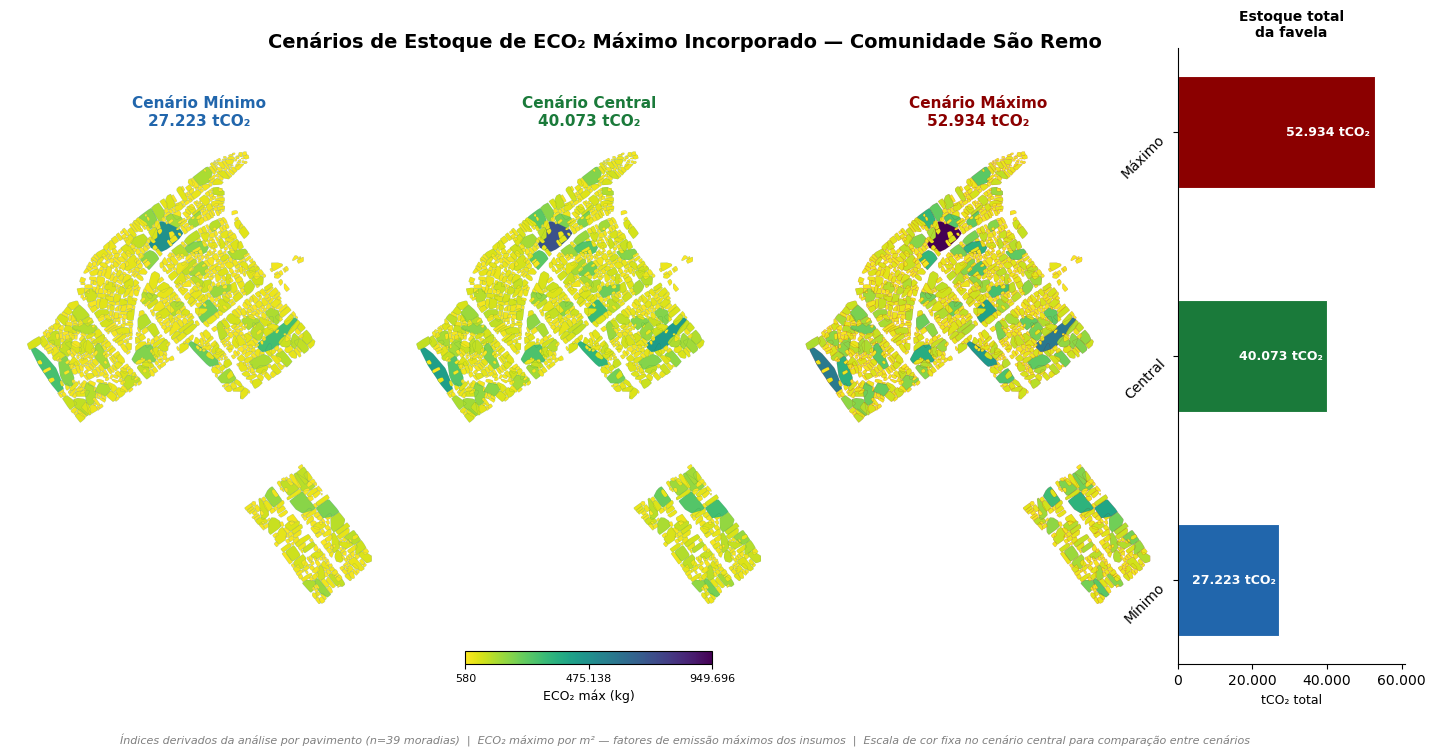


Figura salva: mapa_eco2_sao_remo.png


In [38]:
# ==============================================================================
# 5. FIGURA: três mapas lado a lado + painel de totais
# ==============================================================================

# Reprojetar para visualização se necessário
if gdf.crs and not gdf.crs.is_projected:
    gdf = gdf.to_crs(epsg=31983)   # SIRGAS 2000 UTM zona 23S — ajuste se necessário

cenarios      = ['min', 'central', 'max']
titulos       = ['Cenário Mínimo', 'Cenário Central', 'Cenário Máximo']
cores_cenario = ['#2166ac', '#1a7a3a', '#8b0000']   # azul | verde | vermelho escuro

# Escala de cor comum aos três mapas (eco2_m2 do cenário central como referência)
vmin = gdf['eco2_min_kg'].min()
vmax = gdf['eco2_max_kg'].max()

fig = plt.figure(figsize=(18, 8))
gs  = fig.add_gridspec(1, 4, width_ratios=[3, 3, 3, 1.8], wspace=0.03)

axes_mapas = [fig.add_subplot(gs[i]) for i in range(3)]
ax_totais  = fig.add_subplot(gs[3])

for ax, cenario, titulo, cor in zip(axes_mapas, cenarios, titulos, cores_cenario):

    col_m2 = f'eco2_{cenario}_kg'   # ← cada mapa usa seu próprio cenário

    # Fundo neutro
    gdf.plot(ax=ax, color='#e8e8e8', edgecolor='none')

    # Coroplético pelo ECO₂/m² do cenário central (escala fixa)
    gdf.plot(column=col_m2, ax=ax,
             cmap='viridis_r',
             vmin=vmin, vmax=vmax,
             edgecolor='none',
             linewidth=0.1,
             legend=False)

    # Contorno colorido por cenário para diferenciação
    gdf.boundary.plot(ax=ax, color=cor, linewidth=0.1, alpha=0.7)

    # Total da favela no título do mapa
    total_fmt = f"{totais[cenario]:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')
    ax.set_title(f'{titulo}\n{total_fmt} tCO₂', fontsize=11, fontweight='bold', color=cor, pad=3)
    ax.set_axis_off()

# Barra de cor única (referência ao ECO₂/m²)
sm = ScalarMappable(cmap='viridis_r', norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes_mapas, orientation='horizontal',
                    fraction=0.02, pad=0.04, shrink=0.6)
cbar.set_label('ECO₂ máx (kg)', fontsize=9)
# Número de divisões e formatação
cbar.set_ticks(np.linspace(vmin, vmax, 3))  
cbar.ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(',', '.')))
cbar.ax.tick_params(labelsize=8)              

# ==============================================================================
# 6. PAINEL DE TOTAIS (barras horizontais)
# ==============================================================================
labels_totais = ['Mínimo', 'Central', 'Máximo']
vals          = [totais[c] for c in cenarios]

bars = ax_totais.barh(labels_totais, vals,
                      color=cores_cenario, edgecolor='white',
                      linewidth=0.8, height=0.5)

# Rótulos nas barras
for bar, val in zip(bars, vals):
    val_fmt = f"{val:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')
    ax_totais.text(bar.get_width() * 0.97, bar.get_y() + bar.get_height() / 2,
                   f"{val_fmt} tCO₂",
                   ha='right', va='center',
                   fontsize=9, fontweight='bold', color='white')

ax_totais.set_xlabel('tCO₂ total', fontsize=9)
ax_totais.set_yticks(range(len(labels_totais)))
ax_totais.set_yticklabels(labels_totais, rotation=45, ha='right', va='top')
ax_totais.set_title('Estoque total\nda favela', fontsize=10, fontweight='bold', pad=8)
ax_totais.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')))
ax_totais.spines['top'].set_visible(False)
ax_totais.spines['right'].set_visible(False)
ax_totais.set_xlim(0, max(vals) * 1.15)

# ==============================================================================
# 7. TÍTULO GERAL E EXPORTAÇÃO
# ==============================================================================
fig.suptitle('Cenários de Estoque de ECO₂ Máximo Incorporado — Comunidade São Remo',
             fontsize=14, fontweight='bold', y=0.9)
fig.text(0.5, 0.01,
         'Índices derivados da análise por pavimento (n=39 moradias)  |  '
         'ECO₂ máximo por m² — fatores de emissão máximos dos insumos  |  '
         'Escala de cor fixa no cenário central para comparação entre cenários',
         ha='center', fontsize=8, color='gray', style='italic')

plt.savefig("mapa_eco2_sao_remo.png", bbox_inches='tight', dpi=200)
plt.show()

print("\nFigura salva: mapa_eco2_sao_remo.png")

## 6. Totais da comunidade — todos os índices

Recarrega todos os índices (ECO₂ mín/máx, aço, cimento, custo) e apresenta os
totais da comunidade por cenário, um painel por índice. Salvo em
`totais_cenarios_todos_indices.png`.

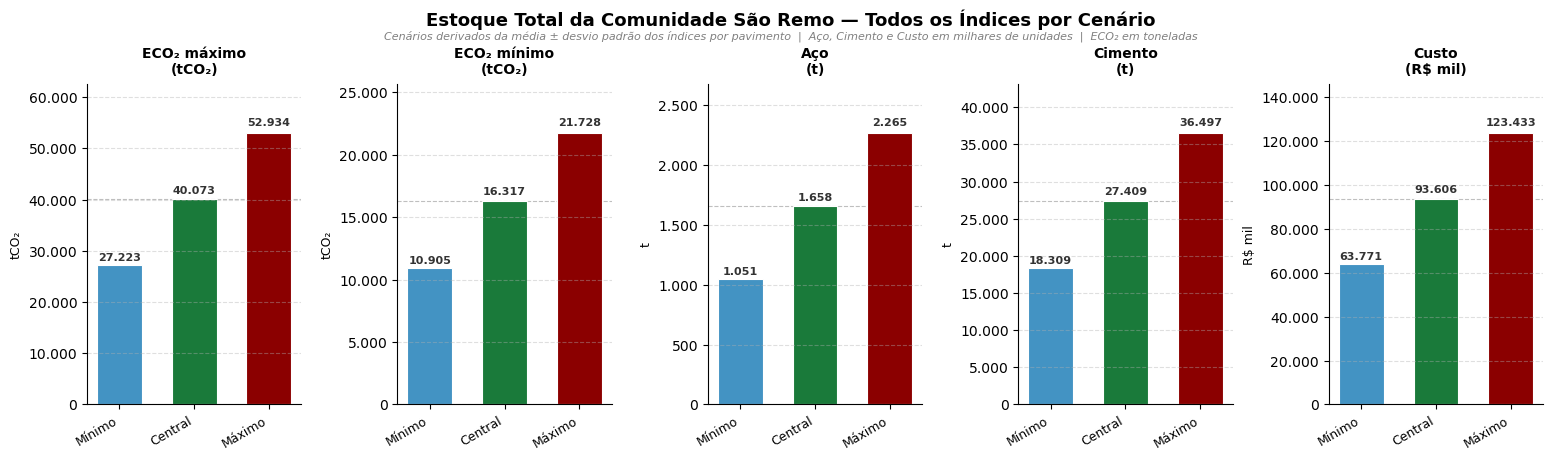

In [26]:
# ==============================================================================
# CÁLCULO DOS TOTAIS PARA TODOS OS ÍNDICES E CENÁRIOS
# ==============================================================================

# Recarregar todos os índices (não apenas ECO₂ máx)
indices_disponiveis = {
    'ECO₂ máximo (kg/m²)' : 'eco2_max',
    'ECO₂ mínimo (kg/m²)' : 'eco2_min',
    'Aço (kg/m²)'          : 'aco',
    'Cimento (kg/m²)'      : 'cimento',
    'Custo (R$/m²)'        : 'custo',
}

unidades = {
    'eco2_max' : 'tCO₂',
    'eco2_min' : 'tCO₂',
    'aco'      : 't',
    'cimento'  : 't',
    'custo'    : 'R$ mil',
}

# Para cada índice, montar dicionário {num_pav: {cenario: valor}}
def montar_indices(df_idx, nome_indice):
    df_sub = df_idx[df_idx['Índice'] == nome_indice].copy()
    mapa_pav = {'Térreo': 1, 'Pavimento 1': 2, 'Pavimento 2': 3, '≥ Pavimento 3': 4}
    resultado = {}
    for _, row in df_sub.iterrows():
        num = mapa_pav.get(row['Pavimento'])
        if num is not None:
            resultado[num] = {
                'min':     row['Cenário mínimo'],
                'central': row['Central (média)'],
                'max':     row['Cenário máximo'],
            }
    return resultado

def calcular_total_indice(gdf, indices_pav, cenario, divisor=1):
    """Calcula total da favela para um índice e cenário."""
    def eco2_edificacao(row):
        area    = row['area']
        num_pav = row['num_pav1']
        if num_pav <= 0 or pd.isna(num_pav):
            return np.nan
        idx = {k: v[cenario] for k, v in indices_pav.items()}
        total = idx[1] * area
        if num_pav >= 2: total += idx[2] * area
        if num_pav >= 3: total += idx[3] * area
        if num_pav >= 4: total += (num_pav - 3) * idx[4] * area
        return total / divisor
    return gdf.apply(eco2_edificacao, axis=1).sum()

# Calcular todos os totais
resultados = {}
for nome_idx, chave in indices_disponiveis.items():
    indices_pav = montar_indices(df_idx, nome_idx)
    divisor = 1000 if chave in ['eco2_max', 'eco2_min', 'aco', 'cimento'] else 1000  # kg→t ou R$→R$ mil
    resultados[chave] = {
        cenario: calcular_total_indice(gdf, indices_pav, cenario, divisor=1000)
        for cenario in ['min', 'central', 'max']
    }

# ==============================================================================
# FIGURA: barras agrupadas por índice, uma barra por cenário
# ==============================================================================
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.subplots_adjust(left=0.06, right=0.97, top=0.82, bottom=0.18, wspace=0.45)

configs = [
    ('eco2_max', 'ECO₂ máximo',  'tCO₂',   '#8b0000'),
    ('eco2_min', 'ECO₂ mínimo',  'tCO₂',   '#2166ac'),
    ('aco',      'Aço',          't',       '#4a90a4'),
    ('cimento',  'Cimento',      't',       '#b5813e'),
    ('custo',    'Custo',        'R$ mil',  '#720a9f'),
]

cenarios      = ['min', 'central', 'max']
labels_cen    = ['Mínimo', 'Central', 'Máximo']
cores_cenario = ['#4393c3', '#1a7a3a', '#8b0000']

for ax, (chave, titulo, unidade, cor_base) in zip(axes, configs):
    vals = [resultados[chave][c] for c in cenarios]

    bars = ax.bar(labels_cen, vals,
                  color=cores_cenario,
                  edgecolor='white', linewidth=0.8,
                  width=0.6)

    # Rótulos no topo de cada barra
    for bar, val in zip(bars, vals):
        val_fmt = f"{val:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                val_fmt,
                ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#333333')

    # Linha de referência no valor central
    ax.axhline(vals[1], color='gray', linewidth=0.8,
               linestyle='--', alpha=0.5, zorder=0)

    ax.set_title(f'{titulo}\n({unidade})', fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel(unidade, fontsize=9)
    ax.set_ylim(0, max(vals) * 1.18)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f"{x:,.0f}".replace(',', 'X').replace('.', ',').replace('X', '.')))
    ax.set_xticks(range(len(labels_cen)))
    ax.set_xticklabels(labels_cen, rotation=30, ha='right', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Estoque Total da Comunidade São Remo — Todos os Índices por Cenário',
             fontsize=13, fontweight='bold', y=0.97)
fig.text(0.5, 0.91,
         'Cenários derivados da média ± desvio padrão dos índices por pavimento  |  '
         'Aço, Cimento e Custo em milhares de unidades  |  ECO₂ em toneladas',
         ha='center', fontsize=8, color='gray', style='italic')

plt.savefig("totais_cenarios_todos_indices.png", bbox_inches='tight', dpi=150)
plt.show()